In [ ]:
# Cell 1 — Install dependencies

!pip install tensorflow opencv-python scikit-learn matplotlib seaborn pillow tqdm

In [5]:
from PIL import Image, UnidentifiedImageError
from pathlib import Path

DATASET_PATH = r"E:\College\SEM - 6\Deep Learning\DL Project\real_and_fake_face_detection\real_and_fake_face"

CLASS_DIRS = {
    "real": "training_real",
    "fake": "training_fake"
}

for label, folder in CLASS_DIRS.items():
    files = list((Path(DATASET_PATH) / folder).glob("*"))
    corrupt = 0
    for f in files:
        try:
            img = Image.open(f)
            img.verify()
        except Exception:
            print(f"Corrupt: {f}")
            corrupt += 1
    print(f"[{label}] Total: {len(files)} | Corrupt: {corrupt}")

[real] Total: 1081 | Corrupt: 0
[fake] Total: 960 | Corrupt: 0


In [ ]:
## Splitting Dataset

In [7]:
DATASET_PATH    = r"E:\College\SEM - 6\Deep Learning\DL Project\real_and_fake_face_detection\real_and_fake_face"
OUTPUT_PATH     = r"E:\College\SEM - 6\Deep Learning\DL Project\split_dataset"   # will be created automatically
MODEL_SAVE_PATH = "deepfake_detector.h5"

IMG_SIZE  = (224, 224)
BATCH     = 32
EPOCHS    = 20
LR        = 1e-4
SEED      = 42

CLASS_DIRS = {
    "real": "training_real",
    "fake": "training_fake"
}

In [17]:
# Cell 4 — Train / Val / Test split

In [13]:
import os, shutil, random, cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def split_dataset(dataset_path, class_dirs, output_path, splits=(0.70, 0.15, 0.15), seed=42):
    """Copy images into output_path/train|val|test/real|fake structure."""
    assert abs(sum(splits) - 1.0) < 1e-6, "Splits must sum to 1"
    train_r, val_r, test_r = splits

    for split in ("train", "val", "test"):
        for label in class_dirs:
            Path(output_path, split, label).mkdir(parents=True, exist_ok=True)

    for label, folder in class_dirs.items():
        files = list((Path(dataset_path) / folder).glob("*"))
        random.seed(seed); random.shuffle(files)

        n = len(files)
        n_train = int(n * train_r)
        n_val   = int(n * val_r)

        splits_map = {
            "train": files[:n_train],
            "val":   files[n_train:n_train + n_val],
            "test":  files[n_train + n_val:],
        }

        for split, file_list in splits_map.items():
            for f in tqdm(file_list, desc=f"Copying {split}/{label}"):
                shutil.copy(f, Path(output_path, split, label, f.name))
            print(f"  {split}/{label}: {len(file_list)} images")

split_dataset(DATASET_PATH, CLASS_DIRS, OUTPUT_PATH)

Copying train/real: 100%|██████████| 756/756 [00:01<00:00, 581.53it/s]


  train/real: 756 images


Copying val/real: 100%|██████████| 162/162 [00:00<00:00, 414.61it/s]


  val/real: 162 images


Copying test/real: 100%|██████████| 163/163 [00:00<00:00, 511.41it/s]


...

  train/fake: 672 images


Copying val/fake: 100%|██████████| 144/144 [00:00<00:00, 603.01it/s]


  val/fake: 144 images


Copying test/fake: 100%|██████████| 144/144 [00:00<00:00, 633.98it/s]

  test/fake: 144 images


In [16]:
# Cell 5 — Data generators with augmentation


In [14]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    width_shift_range=0.05,
    height_shift_range=0.05,
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    Path(OUTPUT_PATH) / "train",
    target_size=IMG_SIZE, batch_size=BATCH,
    class_mode="binary", seed=SEED
)
val_gen = val_test_datagen.flow_from_directory(
    Path(OUTPUT_PATH) / "val",
    target_size=IMG_SIZE, batch_size=BATCH,
    class_mode="binary", seed=SEED, shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    Path(OUTPUT_PATH) / "test",
    target_size=IMG_SIZE, batch_size=BATCH,
    class_mode="binary", seed=SEED, shuffle=False
)

print("Class indices:", train_gen.class_indices)

Found 1428 images belonging to 2 classes.
Found 306 images belonging to 2 classes.
Found 307 images belonging to 2 classes.
Class indices: {'fake': 0, 'real': 1}


In [ ]:
# Cell 6 — Build model (EfficientNetB0 + fine-tuning)


In [15]:
def build_model(img_size=224, learning_rate=1e-4):
    base = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3)
    )
    base.trainable = False          # freeze backbone initially

    inputs = tf.keras.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    model.summary()
    return model, base

model, base_model = build_model(IMG_SIZE[0], LR)

16705208/16705208 [==============================] - 3s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 1280)             5120      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                              

In [22]:
import json
import numpy as np
import tensorflow as tf

# Patch JSON encoder to handle EagerTensors and numpy types
class KerasJSONEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, tf.Tensor):
            return obj.numpy().tolist()
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        return super().default(obj)

# Apply the patch globally
json._default_encoder = KerasJSONEncoder()
json.dumps = lambda obj, **kwargs: KerasJSONEncoder(**kwargs).encode(obj)

In [18]:
# Cell 7 — Phase 1: train head only


In [26]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True,
        monitor="val_auc",
        mode="max"
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3
    ),
    # ← ModelCheckpoint removed
]

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks,
)

# Save manually after training
# Save weights only — bypasses the JSON bug in TF 2.10
model.save_weights("best_model_weights.h5")
print("Weights saved → best_model_weights.h5")

Epoch 1/10
45/45 [==============================] - 53s 1s/step - loss: 0.6823 - accuracy: 0.5784 - auc: 0.5841 - val_loss: 0.6748 - val_accuracy: 0.5686 - val_auc: 0.6516 - lr: 1.0000e-04
Epoch 2/10
45/45 [==============================] - 56s 1s/step - loss: 0.6804 - accuracy: 0.5693 - auc: 0.5942 - val_loss: 0.6752 - val_accuracy: 0.5850 - val_auc: 0.6394 - lr: 1.0000e-04
Epoch 3/10
45/45 [==============================] - 54s 1s/step - loss: 0.6797 - accuracy: 0.5679 - auc: 0.5924 - val_loss: 0.6738 - val_accuracy: 0.5915 - val_auc: 0.6439 - lr: 1.0000e-04
Epoch 4/10
45/45 [==============================] - 55s 1s/step - loss: 0.6813 - accuracy: 0.5728 - auc: 0.5886 - val_loss: 0.6719 - val_accuracy: 0.5784 - val_auc: 0.6451 - lr: 1.0000e-04
Epoch 5/10
45/45 [==============================] - 57s 1s/step - loss: 0.6814 - accuracy: 0.5595 - auc: 0.5854 - val_loss: 0.6728 - val_accuracy: 0.5621 - val_auc: 0.6411 - lr: 1.0000e-04
Epoch 6/10
45/45 [==============================] - 56s

In [27]:
# Unfreeze last 20 layers of EfficientNet
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR / 10),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True,
        monitor="val_auc",
        mode="max"
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3
    ),
]

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,   # 20
    callbacks=callbacks,
)

# Save weights
model.save_weights("deepfake_detector_weights.h5")
print("Final weights saved → deepfake_detector_weights.h5")

Epoch 1/20
45/45 [==============================] - 67s 1s/step - loss: 0.6802 - accuracy: 0.5693 - auc: 0.5883 - val_loss: 0.7191 - val_accuracy: 0.4706 - val_auc: 0.5358 - lr: 1.0000e-05
Epoch 2/20
45/45 [==============================] - 56s 1s/step - loss: 0.6799 - accuracy: 0.5728 - auc: 0.5950 - val_loss: 0.8664 - val_accuracy: 0.5294 - val_auc: 0.5245 - lr: 1.0000e-05
Epoch 3/20
45/45 [==============================] - 57s 1s/step - loss: 0.6789 - accuracy: 0.5595 - auc: 0.5976 - val_loss: 0.9648 - val_accuracy: 0.5294 - val_auc: 0.5262 - lr: 1.0000e-05
Epoch 4/20
45/45 [==============================] - 59s 1s/step - loss: 0.6785 - accuracy: 0.5833 - auc: 0.5971 - val_loss: 1.0179 - val_accuracy: 0.5294 - val_auc: 0.5207 - lr: 1.0000e-05
Epoch 5/20
45/45 [==============================] - 59s 1s/step - loss: 0.6780 - accuracy: 0.5644 - auc: 0.6008 - val_loss: 1.0903 - val_accuracy: 0.5294 - val_auc: 0.5182 - lr: 5.0000e-06
Epoch 6/20
45/45 [==============================] - 68s

In [24]:
print(tf.__version__)
import keras
print(keras.__version__)

2.10.0
2.10.0


=== Class Indices ===
Train: {'fake': 0, 'real': 1}
Val:   {'fake': 0, 'real': 1}

=== Sample Counts ===
Train samples: 1428
Val samples:   306
Train class breakdown: [672 756]
Val class breakdown:   [144 162]

=== Batch Info ===
Image batch shape: (32, 224, 224, 3)
Label batch: [0. 0. 0. 1. 1. 1. 0. 0. 1. 1.]
Image min/max: 0.0 1.0


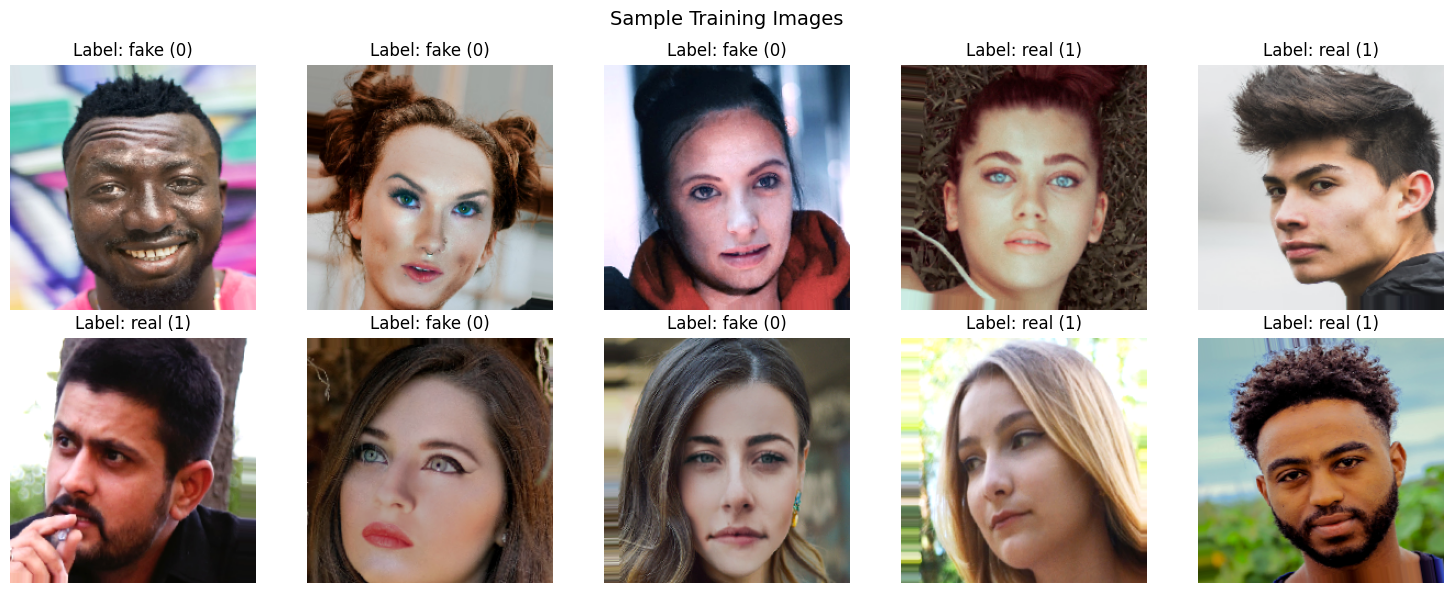


=== Folder Structure ===

train/
  fake/  → 672 images
  real/  → 756 images

val/
  fake/  → 144 images
  real/  → 162 images

test/
  fake/  → 144 images
  real/  → 163 images


In [28]:
# ── Diagnostic Cell ───────────────────────────────────────────────────────

# 1. Check class distribution
print("=== Class Indices ===")
print("Train:", train_gen.class_indices)
print("Val:  ", val_gen.class_indices)

print("\n=== Sample Counts ===")
print("Train samples:", train_gen.samples)
print("Val samples:  ", val_gen.samples)
print("Train class breakdown:", np.bincount(train_gen.classes))
print("Val class breakdown:  ", np.bincount(val_gen.classes))

# 2. Visualize a batch to confirm images load correctly
images, labels = next(train_gen)
print("\n=== Batch Info ===")
print("Image batch shape:", images.shape)
print("Label batch:", labels[:10])
print("Image min/max:", images.min(), images.max())

# 3. Plot sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
class_names = {v: k for k, v in train_gen.class_indices.items()}
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.set_title(f"Label: {class_names[int(labels[i])]} ({labels[i]:.0f})")
    ax.axis("off")
plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()

# 4. Check split folder structure
print("\n=== Folder Structure ===")
for split in ["train", "val", "test"]:
    print(f"\n{split}/")
    for folder in sorted(os.listdir(Path(OUTPUT_PATH) / split)):
        count = len(list((Path(OUTPUT_PATH) / split / folder).glob("*")))
        print(f"  {folder}/  → {count} images")

In [ ]:
#  Cell 5 (redo generators) — add stronger augmentation


In [29]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.15,
    brightness_range=[0.7, 1.3],
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    Path(OUTPUT_PATH) / "train",
    target_size=IMG_SIZE, batch_size=16,   # ← smaller batch for small dataset
    class_mode="binary", seed=SEED
)
val_gen = val_test_datagen.flow_from_directory(
    Path(OUTPUT_PATH) / "val",
    target_size=IMG_SIZE, batch_size=16,
    class_mode="binary", seed=SEED, shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    Path(OUTPUT_PATH) / "test",
    target_size=IMG_SIZE, batch_size=16,
    class_mode="binary", seed=SEED, shuffle=False
)

print("Class indices:", train_gen.class_indices)
print("Train samples:", train_gen.samples)

Found 1428 images belonging to 2 classes.
Found 306 images belonging to 2 classes.
Found 307 images belonging to 2 classes.
Class indices: {'fake': 0, 'real': 1}
Train samples: 1428


In [ ]:
# Cell 6 (rebuild model) — switch to MobileNetV2


In [30]:
def build_model(img_size=224, learning_rate=1e-4):
    base = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3)
    )
    base.trainable = False

    inputs = tf.keras.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    model.summary()
    return model, base

model, base_model = build_model(IMG_SIZE[0], LR)

9406464/9406464 [==============================] - 1s 0us/step
Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 batch_normalization_1 (Batc  (None, 1280)             5120      
 hNormalization)                                                 
                                                                 
 dense_2 (Dense)             (None, 128)               163968 

In [ ]:
# Cell 7 (Phase 1) — longer training


In [31]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=8,
        restore_best_weights=True,
        monitor="val_auc",
        mode="max"
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.5,
        patience=4,
        mode="max"
    ),
]

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,            # ← more epochs
    callbacks=callbacks,
)

model.save_weights("best_model_weights.h5")
print("Weights saved → best_model_weights.h5")

Epoch 1/30
90/90 [==============================] - 42s 450ms/step - loss: 0.9184 - accuracy: 0.5238 - auc: 0.5372 - val_loss: 0.7070 - val_accuracy: 0.5163 - val_auc: 0.5612 - lr: 1.0000e-04
Epoch 2/30
90/90 [==============================] - 51s 567ms/step - loss: 0.7844 - accuracy: 0.5686 - auc: 0.5996 - val_loss: 0.6946 - val_accuracy: 0.5784 - val_auc: 0.6154 - lr: 1.0000e-04
Epoch 3/30
90/90 [==============================] - 60s 667ms/step - loss: 0.7447 - accuracy: 0.5889 - auc: 0.6292 - val_loss: 0.6952 - val_accuracy: 0.5817 - val_auc: 0.6343 - lr: 1.0000e-04
Epoch 4/30
90/90 [==============================] - 53s 586ms/step - loss: 0.7331 - accuracy: 0.6078 - auc: 0.6372 - val_loss: 0.6883 - val_accuracy: 0.6275 - val_auc: 0.6468 - lr: 1.0000e-04
Epoch 5/30
90/90 [==============================] - 40s 440ms/step - loss: 0.7117 - accuracy: 0.6148 - auc: 0.6577 - val_loss: 0.6795 - val_accuracy: 0.6275 - val_auc: 0.6542 - lr: 1.0000e-04
Epoch 6/30
90/90 [======================

In [32]:
# Cell 8 — Phase 2 fine-tuning


In [33]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR / 20),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=8,
        restore_best_weights=True,
        monitor="val_auc",
        mode="max"
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.5,
        patience=4,
        mode="max"
    ),
]

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks,
)

model.save_weights("deepfake_detector_weights.h5")
print("Final weights saved → deepfake_detector_weights.h5")

Epoch 1/30
90/90 [==============================] - 38s 404ms/step - loss: 0.6189 - accuracy: 0.6604 - auc: 0.7319 - val_loss: 0.6322 - val_accuracy: 0.6667 - val_auc: 0.7042 - lr: 5.0000e-06
Epoch 2/30
90/90 [==============================] - 40s 439ms/step - loss: 0.5751 - accuracy: 0.6919 - auc: 0.7702 - val_loss: 0.6321 - val_accuracy: 0.6634 - val_auc: 0.7069 - lr: 5.0000e-06
Epoch 3/30
90/90 [==============================] - 40s 445ms/step - loss: 0.5613 - accuracy: 0.7192 - auc: 0.7828 - val_loss: 0.6400 - val_accuracy: 0.6307 - val_auc: 0.7065 - lr: 5.0000e-06
Epoch 4/30
90/90 [==============================] - 41s 457ms/step - loss: 0.5620 - accuracy: 0.7178 - auc: 0.7847 - val_loss: 0.6424 - val_accuracy: 0.6667 - val_auc: 0.7080 - lr: 5.0000e-06
Epoch 5/30
90/90 [==============================] - 42s 471ms/step - loss: 0.5668 - accuracy: 0.7108 - auc: 0.7810 - val_loss: 0.6343 - val_accuracy: 0.6536 - val_auc: 0.7116 - lr: 5.0000e-06
Epoch 6/30
90/90 [======================

In [34]:
# Cell 9 — Evaluation


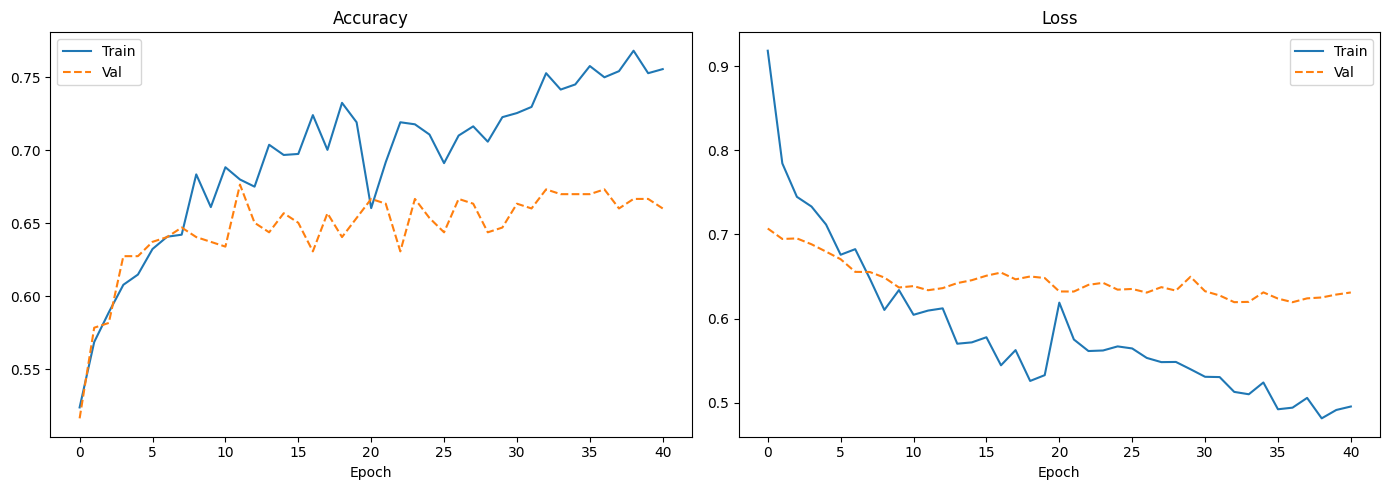

20/20 [==============================] - 11s 554ms/step

Classification Report:
              precision    recall  f1-score   support

        fake       0.59      0.63      0.61       144
        real       0.65      0.61      0.63       163

    accuracy                           0.62       307
   macro avg       0.62      0.62      0.62       307
weighted avg       0.62      0.62      0.62       307

ROC-AUC: 0.6468


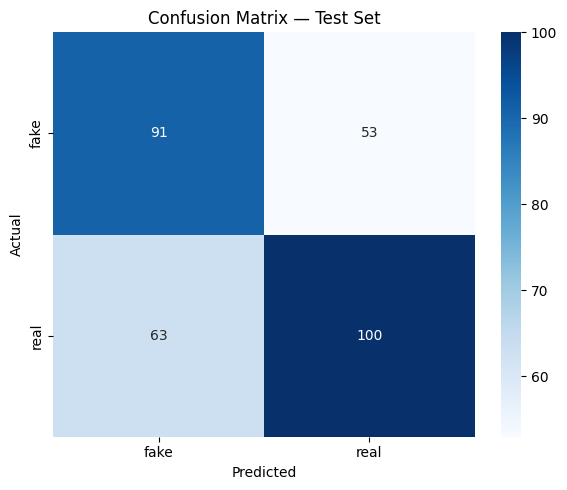

In [35]:
# Combine histories
def combine(h1, h2, key):
    return h1.history[key] + h2.history[key]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, label in zip(axes, ["accuracy", "loss"], ["Accuracy", "Loss"]):
    ax.plot(combine(history1, history2, metric),          label="Train")
    ax.plot(combine(history1, history2, f"val_{metric}"), label="Val", linestyle="--")
    ax.set_title(label); ax.legend(); ax.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

# Test evaluation
test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=1).ravel()
y_true      = test_gen.classes
y_pred      = (y_pred_prob > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_true, y_pred,
      target_names=list(train_gen.class_indices.keys())))
print(f"ROC-AUC: {roc_auc_score(y_true, y_pred_prob):.4f}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["fake", "real"],
            yticklabels=["fake", "real"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

In [41]:
# Get all weights as numpy arrays and save with numpy
import numpy as np

weights = model.get_weights()
np.save("deepfake_weights.npy", weights, allow_pickle=True)
print("Weights exported → deepfake_weights.npy")
print(f"Total weight arrays: {len(weights)}")

Weights exported → deepfake_weights.npy
Total weight arrays: 268


C:\Users\neelk\anaconda3\envs\deepfake\lib\site-packages\numpy\lib\npyio.py:521: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = np.asanyarray(arr)


In [42]:
#  Updated Cell 10 — load with numpy instead


In [43]:
app_code = '''
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
from tensorflow.keras import layers, Model

IMG_SIZE = (224, 224)

@st.cache_resource
def load_model():
    base = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3)
    )
    base.trainable = False
    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = Model(inputs, outputs)

    # Build model by passing a dummy input first
    dummy = np.zeros((1, 224, 224, 3), dtype=np.float32)
    model(dummy, training=False)

    # Load weights saved as numpy
    weights = np.load("deepfake_weights.npy", allow_pickle=True)
    model.set_weights(weights)
    return model

model = load_model()

st.title("Deepfake Face Detector")
st.write("Upload a face image to check if it is **real** or **AI-generated (fake)**.")

uploaded = st.file_uploader("Choose an image", type=["jpg", "jpeg", "png"])

if uploaded:
    img = Image.open(uploaded).convert("RGB")
    st.image(img, caption="Uploaded image", use_column_width=True)

    img_resized = img.resize(IMG_SIZE)
    arr = np.array(img_resized) / 255.0
    arr = np.expand_dims(arr, axis=0)

    with st.spinner("Analysing..."):
        prob = float(model.predict(arr, verbose=0)[0][0])

    # fake=0, real=1 -> prob > 0.5 means real
    label = "REAL" if prob > 0.5 else "FAKE"
    confidence = prob if prob > 0.5 else 1 - prob

    col1, col2 = st.columns(2)
    col1.metric("Prediction", label)
    col2.metric("Confidence", f"{confidence*100:.1f}%")
    st.progress(float(confidence))
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)
print("app.py written! Run:  streamlit run app.py")

app.py written! Run:  streamlit run app.py
